In [1]:

import functools
import openai

def _default_retries(cls):
    original = cls.__init__

    @functools.wraps(original)
    def __init__(self, *args, **kwargs):
        kwargs.setdefault("max_retries", 40)
        original(self, *args, **kwargs)

    cls.__init__ = __init__

for _cls in (openai.OpenAI, openai.AsyncOpenAI):
    _default_retries(_cls)


## Table of Contents

- [Exploring the Dataset](#exploring-the-dataset)
- [A Quick Recap on the Image Understanding API](#a-quick-recap-on-the-image-understanding-api)
- [Structured Data Extraction](#structured-data-extraction)
- [Evals](#evals)
  - [Using the Async API to Concurrently Process Images](#using-the-async-api-to-concurrently-process-images)
  - [Calculating our Evaluation Metrics](#calculating-our-evaluation-metrics)
  - [Error Analysis and Looking at our Data](#error-analysis-and-looking-at-our-data)
- [Custom Schema Parsing with Pydantic and the Structured Outputs API](#custom-schema-parsing-with-pydantic-and-the-structured-outputs-api)
- [Conclusion](#conclusion)

## Exploring the Dataset
The dataset we are using is the Clothing Attributes Dataset, an open-source collection of over 1,000 images of humans in various fashion outfits, freely available on [kaggle](https://www.kaggle.com/datasets/mahdiehhajian/clothing-attributes-dataset). Accompanying the images are ground truth labels describing the attributes present in each image. The original dataset provides these attributes as matrices, but we’ve transformed them into JSON for easier use in this cookbook.

As highlighted in the dataset's [README](https://www.kaggle.com/datasets/mahdiehhajian/clothing-attributes-dataset), the ground truth attributes were obtained via the use of six, paid human labelers. For certain attributes, the ground truth label is "unknown", meaning the six human labelers could not reach an agreement on that attribute.

In [2]:
%pip install --quiet IPython openai matplotlib numpy scikit-learn pydantic tqdm python-dotenv

Note: you may need to restart the kernel to use updated packages.


Let's take a look at a sample image and its accompanying ground truth attributes, you can change the input to the function below to explore different image, attribute pairs to get a feel for the data we're dealing with.

In [3]:
import json


IMAGES_DIR = "data/images"
LABELS_DIR = "data/labels"

with open(f"{LABELS_DIR}/ground_truth_attributes.json") as f:
    ground_truth_attributes = json.load(f)

def get_gt_attributes_by_id(image_id: str) -> dict[str, str]:
    return ground_truth_attributes[int(image_id) - 1] # image_ids start from 1

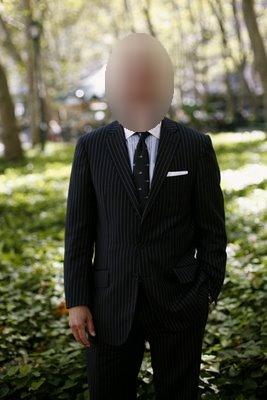

{
  "image_id": "000001",
  "necktie": "yes",
  "collar": "yes",
  "gender": "male",
  "placket": "yes",
  "skin_exposure": "low_exposure",
  "scarf": "no",
  "solid_pattern": "unknown",
  "floral_pattern": "no",
  "spot_pattern": "unknown",
  "graphics_pattern": "no",
  "plaid_pattern": "no",
  "stripe_pattern": "unknown",
  "red": "no",
  "yellow": "no",
  "green": "no",
  "cyan": "no",
  "blue": "no",
  "purple": "no",
  "brown": "no",
  "white": "no",
  "gray": "no",
  "black": "yes",
  "many_colors": "no",
  "sleeve_length": "long_sleeves",
  "neckline": "v_shape",
  "category": "suit"
}


In [4]:
import json

from IPython.display import Image, display


def show_image_and_attributes(image_id="000001"):
    image_path = f"{IMAGES_DIR}/{image_id}.jpg"

    img = Image(image_path)

    attributes = get_gt_attributes_by_id(image_id)
    pretty_json = json.dumps(attributes, indent=2)

    display(img)
    print(pretty_json)


show_image_and_attributes("000001")

Here we can see that the dataset contains a variety of different attributes describing the colors present in the photo, the patterns, and structural features like collars and plackets. If this were an e-commerce application, these would power things like search, filtering, and inventory categorization.

We will use Grok to automate the extraction of these attributes for a given a photo.
Furthermore, because this dataset contains ground truth attributes, we can run evaluations (evals) on our approach to understand the performance of our system. Additionally, these evals can illuminate discrepancies between expected and actual results, serving as a diagnostic tool. This enables targeted investigations into unexpected outcomes, allowing us to systematically refine our approach rather than relying on guesswork.

One thing you may notice, especially with photos containing more complex outfits, is that the attributes/schema is quite simplistic and ambiguous. For example, the color and pattern attributes here don't specify which items they're referring to. It could also be the case that within the same photo, different items of clothing possess different colors and patterns.

But don't worry, later on we'll showcase how we can use Grok to extract data into a new custom schema which is much more flexible and accounts for these shortcomings.

## A Quick recap on the Image Understanding API
Let's start off with simple prompt to `grok-4.7` asking it to describe what it sees in the image.

> **Note:** Make sure to export an env var named `XAI_API_KEY` or set it in a `.env` file at the root of this repo if you want to run the notebook. Head over to our [console](https://console.x.ai/) to obtain an api key if you don't have one already.

In [5]:
import os
from dotenv import load_dotenv

load_dotenv()

XAI_API_KEY=os.getenv("XAI_API_KEY") # set this environment variable in .env file
BASE_URL="https://api.x.ai/v1"

In [6]:
import base64


def base64_encode_image(image_path: str) -> str:
    with open(image_path, "rb") as image_file:
        encoded_string = base64.b64encode(image_file.read()).decode("utf-8")
    return encoded_string


def image_message(image_path: str, prompt: str) -> dict:
    return {
        "role": "user",
        "content": [
            {
                "type": "input_image",
                "image_url": f"data:image/jpeg;base64,{base64_encode_image(image_path)}",
                "detail": "high",
            },
            {"type": "input_text", "text": prompt},
        ],
    }

In [7]:
from openai import OpenAI

GROK_MODEL = "grok-4.7"

grok_client = OpenAI(
    base_url=BASE_URL,
    api_key=XAI_API_KEY
)

In [8]:
def analyze_image(prompt: str, image_path: str) -> str:
    response = grok_client.responses.create(
        model=GROK_MODEL,
        input=[image_message(image_path, prompt)],
    )
    return response.output_text


sample_image = f"{IMAGES_DIR}/000001.jpg"
print(analyze_image("Describe what you see in this image", sample_image))

The image shows a person standing outdoors in a wooded area with lush green foliage. The individual is dressed in a formal dark pinstripe suit, a white dress shirt, a dark patterned tie, and a white pocket square. Their face is blurred for privacy. The background consists of trees and greenery, suggesting a park or garden setting.


Not bad. Just with this very basic prompt, Grok gave a descriptive answer of the photo including detailed information on the man's clothing, even pointing out the pattern on the tie, all without being explicitly told to do so. Let's develop our prompt towards extracting the attributes that are provided as labels in the dataset.

## Structured Data Extraction

In [9]:
from typing import Literal

from pydantic import BaseModel, Field

YesNo = Literal["yes", "no"]


class ClothingAttributes(BaseModel):
    necktie: YesNo
    collar: YesNo
    gender: Literal["male", "female"]
    placket: YesNo
    skin_exposure: Literal["low_exposure", "high_exposure"]
    scarf: YesNo
    solid_pattern: YesNo
    floral_pattern: YesNo
    spot_pattern: YesNo
    graphics_pattern: YesNo
    plaid_pattern: YesNo
    stripe_pattern: YesNo
    red: YesNo
    yellow: YesNo
    green: YesNo
    cyan: YesNo
    blue: YesNo
    purple: YesNo
    brown: YesNo
    white: YesNo
    gray: YesNo
    black: YesNo
    many_colors: YesNo = Field(description="Whether the clothing has more than two colors")
    sleeve_length: Literal["no_sleeves", "short_sleeves", "long_sleeves"]
    neckline: Literal["v_shape", "round", "other"]
    category: Literal["shirt", "sweater", "t_shirt", "outerwear", "suit", "tank_top", "dress"]


attribute_extraction_prompt = "You will be provided with an image of a person wearing some items of clothing. Extract the attributes of their clothing."


def extract_attributes(image_path: str) -> ClothingAttributes:
    response = grok_client.responses.parse(
        model=GROK_MODEL,
        input=[image_message(image_path, attribute_extraction_prompt)],
        text_format=ClothingAttributes,
        reasoning={"effort": "low"},
    )
    return response.output_parsed

Instead of describing the output format in the prompt, we define it as a Pydantic model whose fields match the labels in the dataset, and pass it to `responses.parse`. With [structured outputs](https://docs.x.ai/developers/model-capabilities/text/structured-outputs), the response is guaranteed to match the schema, so there's no JSON to pull out of the text or validate by hand.

We also set `reasoning={"effort": "low"}`. Tagging clothes is mostly about looking carefully rather than working through a multi-step problem, so a lower reasoning effort makes each request faster and cheaper. Once the evals below are set up, you can try the default effort and compare the results. Let's give it a spin!

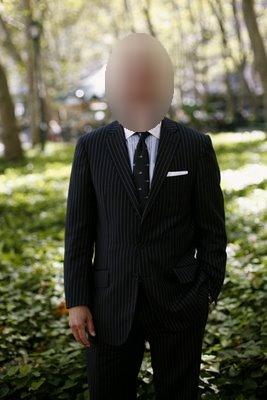

Ground truth:
{
  "image_id": "000001",
  "necktie": "yes",
  "collar": "yes",
  "gender": "male",
  "placket": "yes",
  "skin_exposure": "low_exposure",
  "scarf": "no",
  "solid_pattern": "unknown",
  "floral_pattern": "no",
  "spot_pattern": "unknown",
  "graphics_pattern": "no",
  "plaid_pattern": "no",
  "stripe_pattern": "unknown",
  "red": "no",
  "yellow": "no",
  "green": "no",
  "cyan": "no",
  "blue": "no",
  "purple": "no",
  "brown": "no",
  "white": "no",
  "gray": "no",
  "black": "yes",
  "many_colors": "no",
  "sleeve_length": "long_sleeves",
  "neckline": "v_shape",
  "category": "suit"
}
Grok extracted attributes:
{
  "necktie": "yes",
  "collar": "yes",
  "gender": "male",
  "placket": "yes",
  "skin_exposure": "low_exposure",
  "scarf": "no",
  "solid_pattern": "no",
  "floral_pattern": "no",
  "spot_pattern": "no",
  "graphics_pattern": "no",
  "plaid_pattern": "no",
  "stripe_pattern": "yes",
  "red": "no",
  "yellow": "no",
  "green": "no",
  "cyan": "no",
  "bl

In [10]:
def show_image_and_extracted_attributes(image_id: str = "000001"):
    image_path = f"{IMAGES_DIR}/{image_id}.jpg"

    ground_truth_json = json.dumps(get_gt_attributes_by_id(image_id), indent=2)
    extracted_attributes_json = extract_attributes(image_path).model_dump_json(indent=2)

    display(Image(image_path))
    print("Ground truth:")
    print(ground_truth_json)

    print("Grok extracted attributes:")
    print(extracted_attributes_json)


show_image_and_extracted_attributes()

Ok nice, looks like we're getting back some similar data. However, let's be more scientific about our evaluation approach and write some proper evaluation code. We will run the prompt above on a batch of images and then compare the attributes Grok extracted with the ground truth attributes. This will quantify how accurately Grok identifies each attribute and highlight which ones present challenges or yield inconsistent results.

## Evals

The full dataset contains 1,856 images, and this repo includes the first 250. To keep the run short, we'll evaluate the first 100, and you can raise `NUM_IMAGES` below to evaluate more. Let's leverage the Async API to concurrently process images speeding up our extraction process.

### Using the Async API to Concurrently Process Images

First let's write an async version of our `extract_attributes` function which will leverage an instance of the `AsyncOpenAI` client. We can then call this function concurrently using `asyncio` to minimize the time taken to process a large batch of images.

In [11]:
from openai import AsyncOpenAI


async def extract_attributes_async(client: AsyncOpenAI, image_id: str) -> dict[str, str]:
    image_path = f"{IMAGES_DIR}/{image_id}.jpg"

    try:
        response = await client.responses.parse(
            model=GROK_MODEL,
            input=[image_message(image_path, attribute_extraction_prompt)],
            text_format=ClothingAttributes,
            reasoning={"effort": "low"},
        )
        attributes = response.output_parsed.model_dump()
    except Exception as error:
        print(f"Failed to extract attributes for image with id {image_id}: {error}")
        return {"image_id": image_id}

    # Add the image_id to the predicted attributes for easier identification later
    return {"image_id": image_id, **attributes}

Lets run our new async function with a single image to make sure working.

In [12]:
async_grok_client = AsyncOpenAI(
    api_key=XAI_API_KEY,
    base_url=BASE_URL
)

attributes = await extract_attributes_async(async_grok_client, "000001")
print(json.dumps(attributes, indent=2))

{
  "image_id": "000001",
  "necktie": "yes",
  "collar": "yes",
  "gender": "male",
  "placket": "yes",
  "skin_exposure": "low_exposure",
  "scarf": "no",
  "solid_pattern": "no",
  "floral_pattern": "no",
  "spot_pattern": "yes",
  "graphics_pattern": "no",
  "plaid_pattern": "no",
  "stripe_pattern": "yes",
  "red": "no",
  "yellow": "no",
  "green": "no",
  "cyan": "no",
  "blue": "no",
  "purple": "no",
  "brown": "no",
  "white": "yes",
  "gray": "no",
  "black": "yes",
  "many_colors": "no",
  "sleeve_length": "long_sleeves",
  "neckline": "other",
  "category": "suit"
}


Let's create a function using our new async method to batch-process images, with a `max_in_flight_requests` parameter to cap concurrent requests. You should tune this to match your tier’s rate limits, which you can view via the model's page on the [xAI console](https://console.x.ai) both for `grok-4.7` as well as other models.

In [13]:
import asyncio
from tqdm.asyncio import tqdm


async def analyze_batch(client: AsyncOpenAI, image_ids: list[str], max_in_flight_requests = 10) -> list[dict[str, str]]:
    semaphore = asyncio.Semaphore(max_in_flight_requests)

    async def analyze_with_semaphore(image_id: str) -> dict:
        async with semaphore:
            return await extract_attributes_async(client, image_id)

    tasks = [analyze_with_semaphore(image_id) for image_id in image_ids]
    results = []
    for task in tqdm.as_completed(tasks, total=len(tasks), desc="Analyzing images"):
        result = await task
        results.append(result)
    return results

In [14]:
from pathlib import Path

NUM_IMAGES = 100

image_ids = [image_path.stem for image_path in sorted(Path(IMAGES_DIR).glob("*.jpg"))]
image_ids_subset = image_ids[:NUM_IMAGES]

grok_predictions = await analyze_batch(async_grok_client, image_ids_subset, max_in_flight_requests=5)

Analyzing images:   0%|          | 0/100 [00:00<?, ?it/s]

Analyzing images:   1%|          | 1/100 [00:19<32:04, 19.44s/it]

Analyzing images:   3%|▎         | 3/100 [00:19<08:28,  5.24s/it]

Analyzing images:   4%|▍         | 4/100 [00:23<07:18,  4.57s/it]

Analyzing images:   5%|▌         | 5/100 [00:23<04:56,  3.13s/it]

...

Analyzing images:  97%|█████████▋| 97/100 [05:29<00:08,  2.91s/it]

Analyzing images:  98%|█████████▊| 98/100 [05:51<00:17,  8.71s/it]

Analyzing images:  99%|█████████▉| 99/100 [06:08<00:11, 11.08s/it]

Analyzing images: 100%|██████████| 100/100 [06:16<00:00, 10.18s/it]

Analyzing images: 100%|██████████| 100/100 [06:16<00:00,  3.76s/it]

In [15]:
valid_grok_predictions = []
invalid_grok_predictions = []
for prediction in grok_predictions:
    if len(prediction.keys()) == 1: # only the image_id means the request failed, so leave it out of the result set
        invalid_grok_predictions.append(prediction["image_id"])
    else:
        valid_grok_predictions.append(prediction)

if len(invalid_grok_predictions) > 0:
    print(f"Failed to extract attributes for images with IDs: {invalid_grok_predictions}, excluding from result set")
else:
    print("All images analyzed successfully")

valid_grok_predictions.sort(key=lambda prediction: prediction["image_id"])

All images analyzed successfully


### Calculating our Evaluation Metrics

Now that we've gathered our extracted attributes using Grok (our predictions), we'll compare them against the ground truth attributes from our dataset and calculate metrics like [accuracy](https://scikit-learn.org/stable/modules/model_evaluation.html#accuracy-score), [precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#precision-score), [recall](https://scikit-learn.org/stable/modules/model_evaluation.html#precision-recall-f-measure-metrics) and [F1 score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html). We'll also show the [confusion matrices](https://scikit-learn.org/stable/modules/model_evaluation.html#confusion-matrix) for each attribute. Finally, if there was a mismatch we'll print the ID of the image and the difference between Grok's prediction and the ground truth label so we can investigate that particular image, attribute pair further.

> **Note:** The metrics calculation below excludes comparison/calculation for ground truth attributes that have a label value of "unknown". In the code below, valid samples for a given attribute are those which have a label which is not "unknown"

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

valid_prediction_ids = [p["image_id"] for p in valid_grok_predictions]
ground_truths = [g for g in ground_truth_attributes if g["image_id"] in valid_prediction_ids]

BINARY_ATTRIBUTES = [
    "necktie",
    "collar",
    "gender",
    "placket",
    "scarf",
    "floral_pattern",
    "graphics_pattern",
    "plaid_pattern",
    "many_colors",
    "red", "yellow", "green", "cyan", "blue", "purple", "brown", "white", "gray", "black",
]

MULTI_CLASS_ATTRIBUTES = ["sleeve_length", "neckline", "category"]

COMPUTED_METRICS = {"binary": {}, "multi_class": {}}
MISMATCHES = {"binary": {}, "multi_class": {}}  # New dictionary to store mismatches

def preprocess_binary(data_list: list[dict[str, str]], attribute: str):
    """Preprocess binary attributes (yes/no or male/female) to 0/1, return labels and validity mask."""
    labels = [item[attribute] for item in data_list]
    if attribute == "gender":
        processed = [1 if x == "male" else 0 if x == "female" else -1 for x in labels]  # -1 for unknown
    else:
        processed = [1 if x == "yes" else 0 if x == "no" else -1 for x in labels]  # -1 for unknown
    return processed

def preprocess_multi_class(data_list: list[dict[str, str]], attribute: str):
    """Preprocess multi class attributes to integers and return label mapping."""
    labels = [item[attribute] for item in data_list]
    unique_values = list(set(labels) - {"unknown"})  # Exclude "unknown"
    if not unique_values:  # Handle case where all are "unknown"
        unique_values = ["unknown"]
    value_to_int = {val: idx for idx, val in enumerate(unique_values)}
    processed_labels = [value_to_int.get(x, -1) for x in labels]  # -1 for unknown
    return processed_labels, unique_values

def capture_mismatches(attribute, y_true, y_pred, actual_data, predicted_data, mask, is_binary=True):
    """Capture mismatches in a list of tuples (image_id, actual, predicted) for the given attribute."""
    mismatch_list = []
    for idx, orig_idx in enumerate(mask):  # Use mask to map back to original indices
        if y_true[idx] != y_pred[idx]:  # Check for mismatch in filtered data
            image_id = actual_data[orig_idx]["image_id"]
            if is_binary:
                if attribute == "gender":
                    actual_val = "male" if y_true[idx] == 1 else "female"
                    pred_val = "male" if y_pred[idx] == 1 else "female"
                else:
                    actual_val = "yes" if y_true[idx] == 1 else "no"
                    pred_val = "yes" if y_pred[idx] == 1 else "no"
            else:
                # For multiclass, use the original string values
                actual_val = actual_data[orig_idx][attribute]
                pred_val = predicted_data[orig_idx][attribute]
            mismatch_list.append((image_id, actual_val, pred_val))
    return mismatch_list

for attribute in BINARY_ATTRIBUTES:
    y_true = preprocess_binary(ground_truths, attribute)
    y_pred = preprocess_binary(valid_grok_predictions, attribute)

    # Filter out samples where either y_true or y_pred is "unknown" (-1)
    mask = [i for i in range(len(y_true)) if y_true[i] != -1 and y_pred[i] != -1]
    y_true_filtered = np.array(y_true)[mask]
    y_pred_filtered = np.array(y_pred)[mask]

    if len(y_true_filtered) > 0:
        accuracy = accuracy_score(y_true_filtered, y_pred_filtered)
        precision = precision_score(y_true_filtered, y_pred_filtered, average='binary', pos_label=1, zero_division=0)
        recall = recall_score(y_true_filtered, y_pred_filtered, average='binary', pos_label=1, zero_division=0)
        f1 = f1_score(y_true_filtered, y_pred_filtered, average='binary', pos_label=1, zero_division=0)
        conf_matrix = confusion_matrix(y_true_filtered, y_pred_filtered)

        COMPUTED_METRICS["binary"][attribute] = {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1
        }

        print(f"\nMetrics for binary attribute: {attribute}")
        print(f"Valid samples: {len(y_true_filtered)}/{len(y_true)}")
        print(f"Accuracy: {accuracy}")
        print(f"Precision: {precision}")
        print(f"Recall: {recall}")
        print(f"F1-Score: {f1}")
        print("Confusion Matrix:")
        print(conf_matrix)

        MISMATCHES["binary"][attribute] = capture_mismatches(attribute, y_true_filtered, y_pred_filtered, ground_truths, valid_grok_predictions, mask, is_binary=True)
    else:
        print(f"No valid data for binary attribute: {attribute} (all samples excluded due to 'unknown')")
        MISMATCHES["binary"][attribute] = []  # Empty list if no valid data

for attribute in MULTI_CLASS_ATTRIBUTES:
    y_true, true_labels = preprocess_multi_class(ground_truths, attribute)
    y_pred, pred_labels = preprocess_multi_class(valid_grok_predictions, attribute)

    # Ensure labels match (use the union of both sets for consistency)
    all_labels = list(set(true_labels + pred_labels))
    value_to_int = {val: idx for idx, val in enumerate(all_labels)}
    y_true_final = [value_to_int.get(x, -1) for x in [ground_truths[i][attribute] for i in range(len(ground_truths))]]
    y_pred_final = [value_to_int.get(x, -1) for x in [valid_grok_predictions[i][attribute] for i in range(len(valid_grok_predictions))]]

    # Filter out -1 (unknown) if any
    mask = [i for i in range(len(y_true_final)) if y_true_final[i] != -1 and y_pred_final[i] != -1]
    y_true_final = np.array(y_true_final)[mask]
    y_pred_final = np.array(y_pred_final)[mask]

    if len(y_true_final) > 0:
        accuracy = accuracy_score(y_true_final, y_pred_final)
        precision = precision_score(y_true_final, y_pred_final, average='weighted', zero_division=0)
        recall = recall_score(y_true_final, y_pred_final, average='weighted', zero_division=0)
        f1 = f1_score(y_true_final, y_pred_final, average='weighted', zero_division=0)
        conf_matrix = confusion_matrix(y_true_final, y_pred_final)

        COMPUTED_METRICS["multi_class"][attribute] = {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1
        }

        print(f"\nMetrics for multi class attribute: {attribute}")
        print(f"Valid samples: {len(y_true_final)}/{len(y_true)}")
        print(f"Accuracy: {accuracy}")
        print(f"Precision: {precision}")
        print(f"Recall: {recall}")
        print(f"F1-Score: {f1}")
        print("Confusion Matrix:")
        print(conf_matrix)

        MISMATCHES["multi_class"][attribute] = capture_mismatches(attribute, y_true_final, y_pred_final, ground_truths, valid_grok_predictions, mask, is_binary=False)
    else:
        print(f"No valid data for multi class attribute: {attribute} (all samples excluded due to 'unknown')")
        MISMATCHES["multi_class"][attribute] = []  # Empty list if no valid data


Metrics for binary attribute: necktie
Valid samples: 89/100
Accuracy: 0.9550561797752809
Precision: 0.8823529411764706
Recall: 0.8823529411764706
F1-Score: 0.8823529411764706
Confusion Matrix:
[[70  2]
 [ 2 15]]

Metrics for binary attribute: collar
Valid samples: 86/100
Accuracy: 0.9186046511627907
Precision: 0.9661016949152542
Recall: 0.9193548387096774
F1-Score: 0.9421487603305785
Confusion Matrix:
[[22  2]
 [ 5 57]]

Metrics for binary attribute: gender
Valid samples: 99/100
Accuracy: 0.9696969696969697
Precision: 0.9814814814814815
Recall: 0.9636363636363636
F1-Score: 0.9724770642201835
Confusion Matrix:
[[43  1]
 [ 2 53]]

Metrics for binary attribute: placket
Valid samples: 100/100
Accuracy: 0.73
Precision: 0.9038461538461539
Recall: 0.6811594202898551
F1-Score: 0.7768595041322314
Confusion Matrix:
[[26  5]
 [22 47]]

Metrics for binary attribute: scarf
Valid samples: 85/100
Accuracy: 0.9294117647058824
Precision: 0.7
Recall: 0.7
F1-Score: 0.7
Confusion Matrix:
[[72  3]
 [ 3  7

Grok performs impressively on the majority of attributes, achieving high accuracy on gender, sleeve length, and necktie detection, demonstrating its strength in clear, distinct visual features. However, Grok does not perform as well on more ambiguous attributes like placket and neckline, or on several of the colors, like black, white and blue. Let’s dive into some of the images where Grok’s predictions differ from the ground truth.

### Error Analysis and Looking at our Data

Here's a small helper that plots the first few images where Grok's prediction for an attribute differs from the ground truth label.

In [17]:
import matplotlib.image as mpimg


def show_mismatches(kind: str, attribute: str, limit: int = 5):
    mismatches = MISMATCHES[kind][attribute][:limit]
    if not mismatches:
        print(f"No mismatches for {attribute}")
        return

    fig, axes = plt.subplots(1, len(mismatches), figsize=(3 * len(mismatches), 4.5), squeeze=False)
    for ax, (image_id, actual, predicted) in zip(axes[0], mismatches):
        ax.imshow(mpimg.imread(f"{IMAGES_DIR}/{image_id}.jpg"))
        ax.axis("off")
        ax.set_title(f"ID: {image_id}\nGrok: {predicted}\nGround truth: {actual}", fontsize=10)
    plt.tight_layout()
    plt.show()

Despite scoring strongly on Gender, there are still a few images where Grok's prediction differed from the ground truth. Let's have a look at some of those images.

In [18]:
for (image_id, ground_truth_gender, predicted_gender) in MISMATCHES["binary"]["gender"]:
    print(f"Image ID: {image_id}, Actual: {ground_truth_gender}, Predicted: {predicted_gender}")

Image ID: 000027, Actual: male, Predicted: female
Image ID: 000077, Actual: female, Predicted: male
Image ID: 000078, Actual: male, Predicted: female


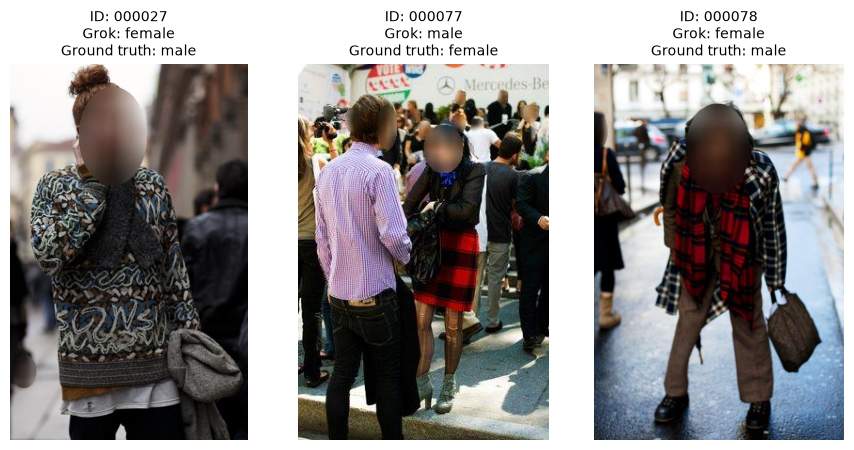

In [19]:
show_mismatches("binary", "gender")

Aha! Take a look at image 000077: there are two people in the foreground, a man in a lavender shirt and a woman in a red skirt, but the schema we asked Grok to use only has room for one gender. Grok described the man, while the labelers described the woman. So it's not that Grok was wrong per se, it's more the case that we made an assumption (only one person per photo) with our data schema that turned out to be false. The other two photos are genuinely hard to call with the faces blurred, a good reminder that attributes inferred from someone's appearance are guesses.

Let's do this for some of the other attributes where we saw lower accuracy such as the neckline attribute.

In [20]:
for (image_id, ground_truth_neckline, predicted_neckline) in MISMATCHES["multi_class"]["neckline"]:
    print(f"Image ID: {image_id}, Actual: {ground_truth_neckline}, Predicted: {predicted_neckline}")

Image ID: 000001, Actual: v_shape, Predicted: other
Image ID: 000006, Actual: v_shape, Predicted: other
Image ID: 000009, Actual: v_shape, Predicted: other
Image ID: 000010, Actual: v_shape, Predicted: other
Image ID: 000012, Actual: v_shape, Predicted: other
Image ID: 000014, Actual: v_shape, Predicted: other
Image ID: 000015, Actual: v_shape, Predicted: other
Image ID: 000017, Actual: v_shape, Predicted: round
Image ID: 000018, Actual: v_shape, Predicted: other
Image ID: 000020, Actual: other, Predicted: round
Image ID: 000021, Actual: v_shape, Predicted: other
Image ID: 000024, Actual: round, Predicted: v_shape
Image ID: 000027, Actual: round, Predicted: other
Image ID: 000028, Actual: v_shape, Predicted: round
Image ID: 000029, Actual: v_shape, Predicted: other
Image ID: 000037, Actual: v_shape, Predicted: other
Image ID: 000039, Actual: v_shape, Predicted: other
Image ID: 000044, Actual: v_shape, Predicted: other
Image ID: 000045, Actual: v_shape, Predicted: other
Image ID: 000046

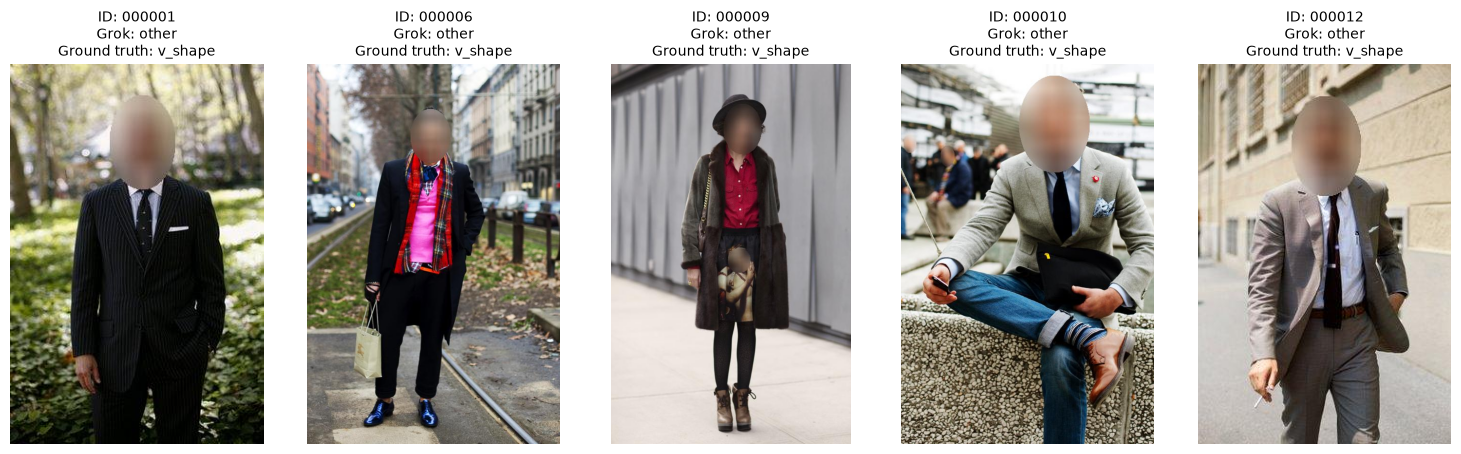

In [21]:
show_mismatches("multi_class", "neckline")

Neckline has the lowest accuracy of any attribute, and the mismatches follow a clear pattern: the labelers said `v_shape` and Grok said `other`. The photos above are all layered outfits, like a suit jacket over a collared shirt and tie. The labelers seem to have labeled the V formed by the jacket's lapels, while Grok looked at the collared shirt underneath, which is neither a V-neck nor a round neck. Neither answer is wrong, the attribute just doesn't say which layer it refers to.

For this guide, all images have also been processed with face blur to preserve privacy, a step not present in the original Clothing Attributes Dataset, where faces are visible. The blur can cover part of the neckline, especially when subjects are distant, which makes its shape even harder to judge.

Let's compare mismatches for some of the color attributes where we saw lower performance to see if we can uncover any other insights.

In [22]:
for (image_id, actual, predicted) in MISMATCHES["binary"]["red"]:
    print(f"Image ID: {image_id}, Actual: {actual}, Predicted: {predicted}")

Image ID: 000006, Actual: no, Predicted: yes
Image ID: 000013, Actual: no, Predicted: yes
Image ID: 000021, Actual: no, Predicted: yes
Image ID: 000022, Actual: no, Predicted: yes
Image ID: 000031, Actual: no, Predicted: yes
Image ID: 000034, Actual: no, Predicted: yes
Image ID: 000046, Actual: no, Predicted: yes
Image ID: 000083, Actual: no, Predicted: yes
Image ID: 000095, Actual: no, Predicted: yes
Image ID: 000096, Actual: no, Predicted: yes


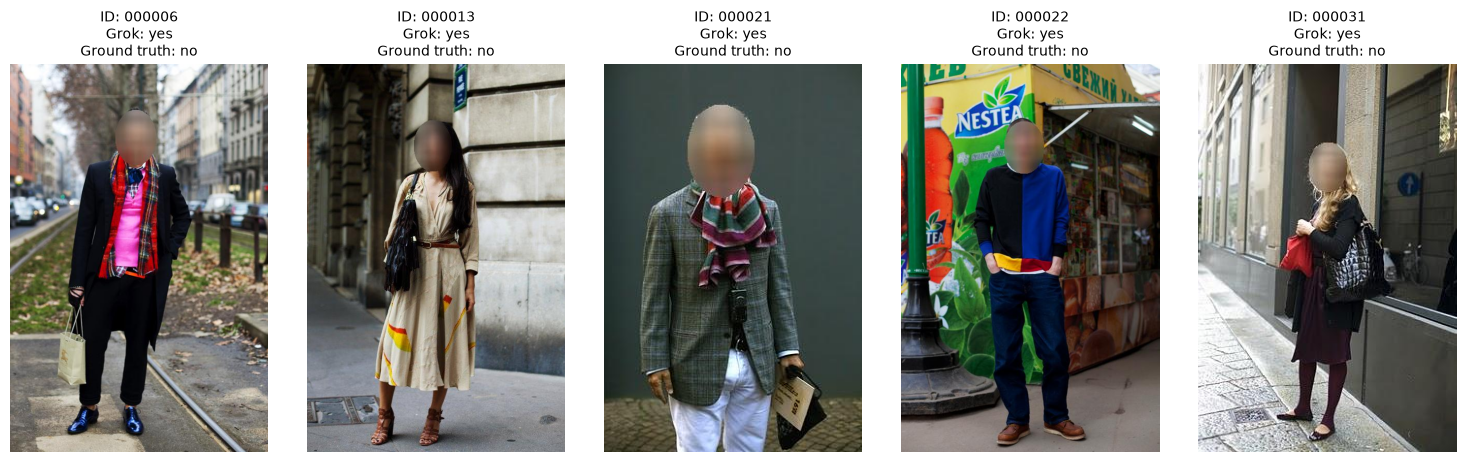

In [23]:
show_mismatches("binary", "red")

The images above are cases where Grok predicted the color red as being present in the image where the ground truth labels did not. What is common across these images is that color red **does** appear in all the images, however it is **not** the color of the primary or central piece of clothing. For example, the scarf of the man in the first image - this could lead us to assume that perhaps the human labelers had specific instructions to only label colors of primary objects of clothing. So actually in this case Grok is doing a good job, since all these images do indeed contain red.

Finally, let's do the same for the color blue.

In [24]:
for (image_id, actual, predicted) in MISMATCHES["binary"]["blue"]:
    print(f"Image ID: {image_id}, Actual: {actual}, Predicted: {predicted}")

Image ID: 000002, Actual: no, Predicted: yes
Image ID: 000003, Actual: no, Predicted: yes
Image ID: 000006, Actual: no, Predicted: yes
Image ID: 000008, Actual: no, Predicted: yes
Image ID: 000010, Actual: no, Predicted: yes
Image ID: 000019, Actual: no, Predicted: yes
Image ID: 000021, Actual: no, Predicted: yes
Image ID: 000027, Actual: no, Predicted: yes
Image ID: 000036, Actual: no, Predicted: yes
Image ID: 000037, Actual: no, Predicted: yes
Image ID: 000041, Actual: no, Predicted: yes
Image ID: 000049, Actual: no, Predicted: yes
Image ID: 000054, Actual: no, Predicted: yes
Image ID: 000057, Actual: no, Predicted: yes
Image ID: 000064, Actual: no, Predicted: yes
Image ID: 000068, Actual: no, Predicted: yes
Image ID: 000074, Actual: no, Predicted: yes
Image ID: 000076, Actual: no, Predicted: yes
Image ID: 000078, Actual: no, Predicted: yes
Image ID: 000079, Actual: no, Predicted: yes
Image ID: 000083, Actual: no, Predicted: yes
Image ID: 000086, Actual: no, Predicted: yes
Image ID: 

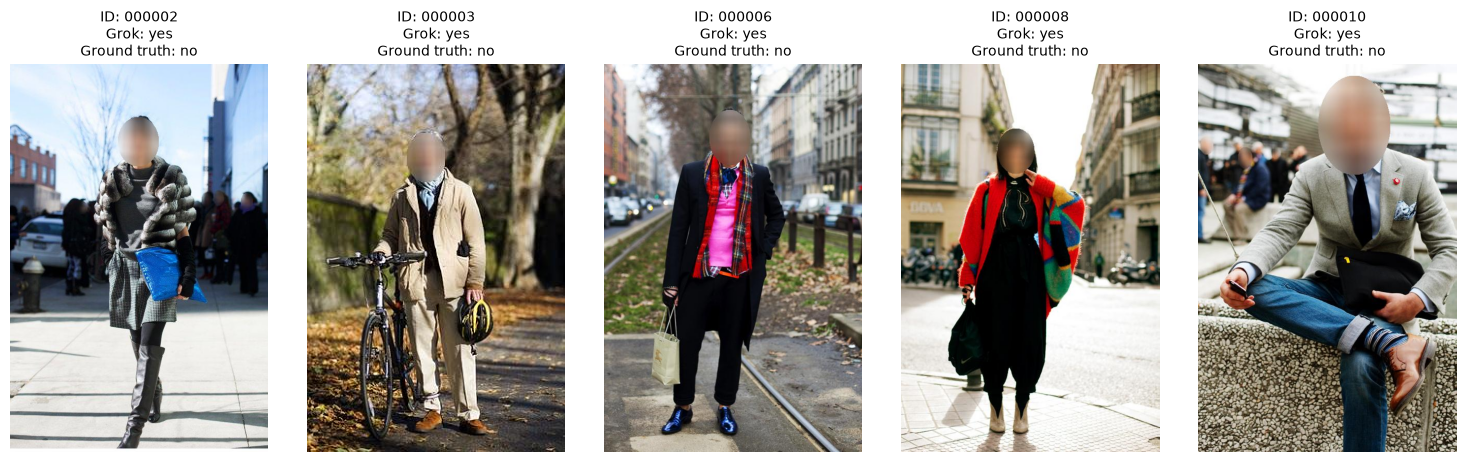

In [25]:
show_mismatches("binary", "blue")

The images above show cases where Grok detected the color blue where the ground truth labels did not. Blue does show up in all of them, but on a bag, a scarf, a pair of shoes or a pair of jeans rather than on the main top, which is what the labels seem to describe. Our prompt asked about the clothing in general, so Grok counted everything, and the same mismatch likely explains the lower scores for black, white and many colors. This touches on an important detail - it's important that the evals we use to assess model performance are tightly calibrated to the desired outcome in the real world. In this case, since we somewhat retrofitted this online dataset for this cookbook, the ground truth attributes differ to the expectations we had.

The importance of this exercise, manually inspecting our data and comparing discrepancies between actual and expected results, cannot be overstated, especially when deploying GenAI/LLM-powered software in production. This process exposed a naive assumption we had made: that each photo in our dataset would feature only one person. Digging into these failure cases through error analysis is critical. It not only reveals hidden edge cases like multiple people, occlusions etc but also shines a light on flawed assumptions baked into our approach. By systematically studying where and why our system stumbles, we can prioritize fixes, refine our model, prompts and approach to handle real-world complexity, and build more robust, reliable software rather than relying on oversimplified expectations.

So, looking at our data uncovered a few shortcomings of the schema we're using to extract attributes:
1. It doesn't account for multiple people in a single image
2. It doesn't seem to handle multiple colors well
3. It doesn't explicitly define which item of clothing each color, pattern or neckline belongs to.

Let’s create a custom schema to tackle all these challenges effectively. We'll design a richer, nested Pydantic model that describes each person and each item of clothing separately, then use structured outputs again to have Grok fill it in straight from the image, in a single request. Let’s see how this works in practice.

## Custom Schema Parsing with Pydantic and the Structured Outputs API

In [26]:
from enum import Enum

from pydantic import BaseModel, Field


class Gender(str, Enum):
    MALE = "male"
    FEMALE = "female"


class Pattern(str, Enum):
    SOLID = "solid"
    FLORAL = "floral"
    SPOT = "spot"
    GRAPHICS = "graphics"
    PLAID = "plaid"
    STRIPE = "stripe"
    OTHER = "other"


class Neckline(str, Enum):
    V_SHAPE = "V-shape"
    ROUND = "Round"
    OTHER_SHAPES = "Other shapes"


class SkinExposure(str, Enum):
    LOW = "low_exposure"
    MODERATE = "moderate_exposure"
    HIGH = "high_exposure"


class SleeveLength(str, Enum):
    NO_SLEEVES = "no_sleeves"
    SHORT_SLEEVE = "short_sleeve"
    LONG_SLEEVE = "long_sleeve"


class AgeGroup(str, Enum):
    CHILD = "child"
    TEEN = "teen"
    ADULT = "adult"
    SENIOR = "senior"


class Posture(str, Enum):
    STANDING = "standing"
    SITTING = "sitting"
    WALKING = "walking"


class ClothingItem(BaseModel):
    name: str = Field(..., description="Type of clothing item (e.g., shirt, pants, necktie)")
    colors: list[str] = Field(..., description="List of colors of the clothing item")
    pattern: Pattern = Field(..., description="Primary pattern of the clothing item")
    sleeve_length: SleeveLength | None = Field(None, description="Length of sleeves, if applicable, set to None if not applicable to item of clothing identified")
    neckline: Neckline | None = Field(None, description="Shape of the neckline, if applicable, set to None if not applicable to item of clothing identified")
    collar: bool | None = Field(None, description="Presence of a collar, set to None if not applicable to item of clothing identified")
    placket: bool | None = Field(None, description="Presence of a placket, set to None if not applicable to item of clothing identified")


class Person(BaseModel):
    gender: Gender = Field(..., description="Gender of the person")
    skin_exposure: SkinExposure = Field(..., description="Overall skin exposure level")
    clothing_items: list[ClothingItem] = Field(..., description="List of clothing items worn")
    age_group: AgeGroup = Field(..., description="Estimated age group of the person")
    posture: Posture = Field(..., description="Physical posture of the person")
    hair_presence: bool = Field(..., description="Whether hair is visible")


class AnnotatedImage(BaseModel):
    persons: list[Person] = Field(..., description="List of people in the image")

The Pydantic model we’ve designed overcomes the limitations of our original schema by providing a more robust and detailed structure. We’ve created a `ClothingItem` model with relevant attributes, enabling finer-grained analysis of individual clothing pieces. Notably, this model supports multiple colors per item, adding flexibility. We’ve also introduced a `Person` model, which links a person to multiple clothing items they’re wearing, also we've introduced some new attributes entirely at the person level such as `age_group`, `posture` and `hair_presence`. Finally, at the top level, we have the `AnnotatedImage` model, which encapsulates one or more people, tying everything together into a comprehensive representation of the image’s content.

In [27]:
multi_person_analysis_prompt = """You are analyzing a photo for a fashion catalog. Look at each person in the photo individually, and describe them and every item of clothing they're wearing, including smaller items and accessories like hats and scarves.

For each clothing item, note its type, its colors, and its main pattern. For tops and dresses, also note the sleeve length, the neckline, and whether it has a collar or a placket (a strip of fabric with buttons). Leave these out for items where they don't apply, like pants.

For each person, also estimate their gender, how much skin is showing, their age group and posture, and whether their hair is visible.

Be thorough: make sure you don't miss any people or clothing items that are visible in the photo."""

In [28]:
async def advanced_extraction(client: AsyncOpenAI, prompt: str, image_id: str) -> AnnotatedImage:
    response = await client.responses.parse(
        model=GROK_MODEL,
        input=[image_message(f"{IMAGES_DIR}/{image_id}.jpg", prompt)],
        text_format=AnnotatedImage,
    )
    return response.output_parsed

In [29]:
annotated_image = await advanced_extraction(async_grok_client, multi_person_analysis_prompt, "000104")

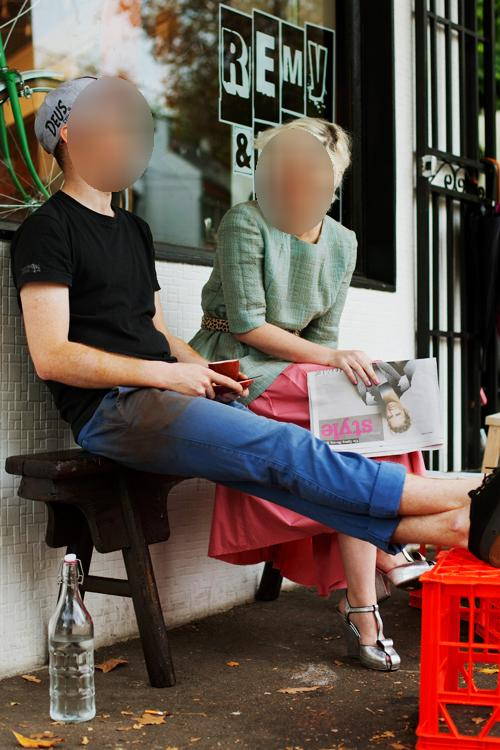

{
  "persons": [
    {
      "gender": "male",
      "skin_exposure": "moderate_exposure",
      "clothing_items": [
        {
          "name": "cap",
          "colors": [
            "grey"
          ],
          "pattern": "graphics",
          "sleeve_length": null,
          "neckline": null,
          "collar": null,
          "placket": null
        },
        {
          "name": "t-shirt",
          "colors": [
            "black"
          ],
          "pattern": "solid",
          "sleeve_length": "short_sleeve",
          "neckline": "Round",
          "collar": false,
          "placket": false
        },
        {
          "name": "pants",
          "colors": [
            "blue"
          ],
          "pattern": "solid",
          "sleeve_length": null,
          "neckline": null,
          "collar": null,
          "placket": null
        }
      ],
      "age_group": "adult",
      "posture": "sitting",
      "hair_presence": false
    },
    {
      "gender": "female

In [30]:
pretty_json = annotated_image.model_dump_json(indent=2)
display(Image(data=f"{IMAGES_DIR}/000104.jpg"))
print(pretty_json)

Awesome, Grok successfully identified both subjects in the image along with their gender, clothing details, including colors and patterns at the individual item level. It also accurately extracted our newly added attributes such as posture and age group. It’s impressive to note that we’ve taken an image as input and, in mere seconds, transformed it into a structured, hierarchical Pydantic model. With the data organized in this format, it becomes trivial to execute a variety of downstream tasks, such as saving it to a database, conducting detailed fashion trend analysis, or enabling automated tagging and categorization for further processing.

Since we don't have explicitly labeled data for this new schema, we can't run evals on it without gathering those first. However, we encourage you to test out the flow above on different images to see how it performs, try tweaking the prompt and Pydantic model to see what other cool things you can extract.

## Conclusion

That wraps up our exploration of some powerful tools and techniques in this guide! We’ve walked through using Grok’s image understanding to pull structured data from images, harnessing the `AsyncOpenAI` client for efficient processing of many images, and digging into evaluations with ground truth labels to reveal where the model shines, where it stumbles and highlighting edge cases and assumptions about our data. By combining image understanding with structured outputs, we’ve also seen how to shape complex data into custom schemas tailored to your needs.


The xAI team is hard at work improving these capabilities with every update, and we’re excited to see what you’ll build with them. Be sure to check out our [docs page](https://docs.x.ai) for more details on all things related to developing with xAI’s APIs!